# 📊 Project 01 — Customer Retention & Revenue Analytics
## Step 4: Churn Prediction Model

**Goal:** Train a machine learning model that predicts whether a customer will churn.

### What is Machine Learning in Simple Terms?
> Imagine teaching a child to recognise cats. You show them 1,000 photos: *"this is a cat, this is NOT a cat."*
> After seeing enough examples, the child can identify a cat they've never seen before.
> 
> Machine learning works the same way — we show the model thousands of customer examples
> (churned or not) and it **learns the pattern** to predict future churn.

### Models we'll train:
| Model | What It Does | Best For |
|---|---|---|
| **Logistic Regression** | Finds a line separating churned vs retained | Baseline, easy to explain |
| **Random Forest** ⭐ | Builds hundreds of decision trees and votes | Best accuracy |

---

## 📦 Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: the machine learning library
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer

%matplotlib inline
sns.set_theme(style="whitegrid")

# Create output folders
MODEL_DIR = "./outputs/model"
CHART_DIR = "./outputs/charts"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

print("✅ All libraries loaded!")

✅ All libraries loaded!


## 📥 Cell 2: Load the Master Analytics Table

In [2]:
MAT_PATH = "./data/mat/master_analytics_table.csv"

mat = pd.read_csv(MAT_PATH)

print(f"✅ MAT loaded: {mat.shape[0]:,} rows × {mat.shape[1]} columns")
print(f"   Churn rate: {mat['churned'].mean()*100:.1f}%")
mat.head(2)

✅ MAT loaded: 12,000 rows × 64 columns
   Churn rate: 23.8%


,subscription_id,user_id,plan_id_sub,plan_name_sub,billing_cycle,monthly_price_usd,mrr_usd,status,start_date,cancel_date,...,feature_adoption_score,login_frequency_monthly,failed_payment_rate,events_per_day,cohort_month,rfm_recency,rfm_frequency,rfm_monetary,rfm_score,risk_segment
0,SUB-000001,USR-00001,PLN-003,Professional,Monthly,79.99,79.99,Active,2021-02-21,NaN,...,8,0.383251,0.042553,0.141945,2021-02,3,3,4,10,Medium Risk
1,SUB-000002,USR-00002,PLN-001,Basic,Annual,9.99,8.33,Active,2021-03-07,NaN,...,8,0.473118,0.000000,0.143369,2021-03,4,4,1,9,Medium Risk


## 🎯 Cell 3: Select Features (Input Columns) and Target (Output Column)

- **Features (X)** = the columns the model uses as clues (e.g. tenure, logins, plan)
- **Target (y)** = the column we want to predict = `churned` (0 = stayed, 1 = left)

In [3]:
# ── Number columns (continuous values) ──────────────────────
NUMERIC_FEATURES = [
    "tenure_days",              # How long they've been a customer
    "mrr_usd",                  # Monthly revenue from this customer
    "total_logins",             # Total login count
    "distinct_features",        # How many features they've used
    "avg_session_dur",          # Average time per session
    "days_since_last_login",    # Recency of activity
    "days_since_last_payment",  # Recency of payment
    "avg_monthly_spend",        # Average spend per month
    "feature_adoption_score",   # 0-10 feature usage score
    "login_frequency_monthly",  # Logins per month
    "failed_payment_rate",      # % of payments that failed
    "events_per_day",           # Overall engagement level
    "nps_score",                # Customer satisfaction score
    "rfm_score",                # Overall health score (Recency+Frequency+Monetary)
    "total_payments",           # Total number of payments made
    "upgrade_count",            # Times they upgraded their plan
    "downgrade_count",          # Times they downgraded (bad sign)
]

# ── Category columns (text values) ─────────────────────────
# Identify plan_name column (may have suffix _x from join)
plan_col = "plan_name_x" if "plan_name_x" in mat.columns else "plan_name"

CATEGORICAL_FEATURES = [
    plan_col,               # Which plan they're on (Basic, Standard, etc.)
    "acquisition_channel", # How they found us (Organic, Paid, Referral, etc.)
    "billing_cycle",       # Monthly or Annual billing
    "gender",              # Customer gender
    "company_size",        # Size of their company
]

# TARGET: What we're trying to predict
TARGET = "churned"   # 0 = stayed, 1 = churned

# Only keep columns that actually exist in the data
NUMERIC_FEATURES     = [c for c in NUMERIC_FEATURES     if c in mat.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in mat.columns]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Create the modelling dataset — drop rows with missing numeric values
df = mat[ALL_FEATURES + [TARGET]].copy()
df = df.dropna(subset=NUMERIC_FEATURES)

print(f"✅ Features selected:")
print(f"   Numeric    : {len(NUMERIC_FEATURES)} columns")
print(f"   Categorical: {len(CATEGORICAL_FEATURES)} columns")
print(f"   Total rows for modelling: {len(df):,}")
print(f"\n   Target breakdown:")
print(df[TARGET].value_counts().rename({0: "Retained (0)", 1: "Churned (1)"}).to_string())

✅ Features selected:
   Numeric    : 17 columns
   Categorical: 4 columns
   Total rows for modelling: 12,000

   Target breakdown:
churned
Retained (0)    9145
Churned (1)     2855


## ✂️ Cell 4: Split Data into Train / Validation / Test Sets

We split the data into **3 groups** — this ensures our model is evaluated fairly on data it has NEVER seen:

| Split | Size | Purpose |
|---|---|---|
| **Training Set** | 70% | The model LEARNS from this data |
| **Validation Set** | 15% | We TUNE the model using this |
| **Test Set** | 15% | Final EVALUATION — never touched until the end |

In [4]:
X = df[ALL_FEATURES]
y = df[TARGET]

# Total number of rows
n = len(df)

# Calculate split boundaries
train_end = int(n * 0.70)   # 70% for training
val_end   = int(n * 0.85)   # next 15% for validation
# remaining 15% = test set

# Split using index positions (this preserves time order)
X_train, y_train = X.iloc[:train_end],  y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],   y.iloc[val_end:]

print("✅ Data Split Complete:")
print(f"   Training Set   : {len(X_train):,} customers ({len(X_train)/n*100:.0f}%)")
print(f"   Validation Set : {len(X_val):,}  customers ({len(X_val)/n*100:.0f}%)")
print(f"   Test Set       : {len(X_test):,}  customers ({len(X_test)/n*100:.0f}%)")

✅ Data Split Complete:
   Training Set   : 8,400 customers (70%)
   Validation Set : 1,800  customers (15%)
   Test Set       : 1,800  customers (15%)


## 🔧 Cell 5: Build Preprocessing Pipeline

Before feeding data to the model, we need to **preprocess** it:

- **Numeric columns** → Scale to same range (so large numbers like `tenure_days=1000` don't overpower small ones like `nps_score=8`)
- **Categorical columns** → Convert text to numbers using **One-Hot Encoding** (e.g., `plan=Basic` becomes columns: `plan_Basic=1, plan_Standard=0, ...`)

In [5]:
# StandardScaler: transforms numeric columns so they all have mean=0, std=1
# OneHotEncoder: converts text categories into binary 0/1 columns

preprocessor = ColumnTransformer([
    ("scale_numbers", StandardScaler(),  NUMERIC_FEATURES),
    ("encode_text",   OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                      CATEGORICAL_FEATURES),
])

print("✅ Preprocessor created:")
print(f"   - StandardScaler  → applied to {len(NUMERIC_FEATURES)} numeric columns")
print(f"   - OneHotEncoder   → applied to {len(CATEGORICAL_FEATURES)} categorical columns")

✅ Preprocessor created:
   - StandardScaler  → applied to 17 numeric columns
   - OneHotEncoder   → applied to 4 categorical columns


## 🤖 Cell 6: Train Both Models

We use a **Pipeline** which chains preprocessing + model together in one step.
This ensures we never accidentally apply preprocessing to the test set at the wrong time.

In [6]:
# Define both models inside Pipelines
models = {

    "Logistic Regression (Baseline)": Pipeline([
        ("prep", preprocessor),
        ("clf",  LogisticRegression(
            max_iter=1000,         # max iterations to find the best line
            C=0.1,                 # regularisation: lower = simpler model
            class_weight="balanced", # handle imbalanced churn/non-churn ratio
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("clf",  RandomForestClassifier(
            n_estimators=200,      # 200 decision trees
            max_depth=10,          # trees can't go deeper than 10 levels
            class_weight="balanced",
            random_state=42,
            n_jobs=-1              # use all CPU cores for speed
        ))
    ]),
}

results = {}   # store results for each model

print("🤖 Training models...")
print("   (This may take 30-60 seconds for Random Forest)\n")

for name, pipeline in models.items():

    # Step 1: Train on training data
    pipeline.fit(X_train, y_train)

    # Step 2: Predict churn probability for validation and test sets
    # predict_proba gives probability: [prob_not_churn, prob_churn]
    # We take [:,1] which is the probability of churning
    prob_val  = pipeline.predict_proba(X_val)[:,1]
    prob_test = pipeline.predict_proba(X_test)[:,1]

    # Step 3: Calculate AUC-ROC scores
    auc_val  = roc_auc_score(y_val,  prob_val)
    auc_test = roc_auc_score(y_test, prob_test)

    results[name] = {
        "pipeline":  pipeline,
        "val_auc":   auc_val,
        "test_auc":  auc_test,
        "prob_test": prob_test
    }

    print(f"  [{name}]")
    print(f"    Validation AUC-ROC : {auc_val:.4f}")
    print(f"    Test AUC-ROC       : {auc_test:.4f}")
    print()

print("✅ Both models trained!")

🤖 Training models...
   (This may take 30-60 seconds for Random Forest)

  [Logistic Regression (Baseline)]
    Validation AUC-ROC : 0.9967
    Test AUC-ROC       : 0.9971

  [Random Forest]
    Validation AUC-ROC : 0.9968
    Test AUC-ROC       : 0.9961

✅ Both models trained!


## 📋 Cell 7: Detailed Evaluation of Best Model

### Understanding the metrics:
- **AUC-ROC**: 0.5 = random guessing, 1.0 = perfect. Target: >0.85
- **Precision**: Of all customers we flagged as churners, how many actually churned?
- **Recall**: Of all customers who actually churned, how many did we catch?
- **F1 Score**: Balanced average of Precision and Recall

In [7]:
# Pick the model with highest test AUC
best_name = max(results, key=lambda k: results[k]["test_auc"])
best      = results[best_name]

print(f"⭐ BEST MODEL: {best_name}")
print(f"   Test AUC-ROC: {best['test_auc']:.4f}\n")

# Convert probabilities to 0/1 predictions (threshold = 0.5)
# If churn probability > 50%, predict churn
y_pred = (best["prob_test"] > 0.5).astype(int)

print("Classification Report:")
print("-" * 50)
print(classification_report(
    y_test, y_pred,
    target_names=["Retained (0)", "Churned (1)"]
))

⭐ BEST MODEL: Logistic Regression (Baseline)
   Test AUC-ROC: 0.9971

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

Retained (0)       0.99      0.98      0.98      1403
 Churned (1)       0.92      0.97      0.94       397

    accuracy                           0.97      1800
   macro avg       0.96      0.97      0.96      1800
weighted avg       0.98      0.97      0.98      1800



## 📊 Cell 8: Chart — ROC Curve + Confusion Matrix

- **ROC Curve**: Shows how well the model separates churned vs retained. The more the curve hugs the top-left corner, the better.
- **Confusion Matrix**: Shows actual vs predicted — how many did we get right/wrong?

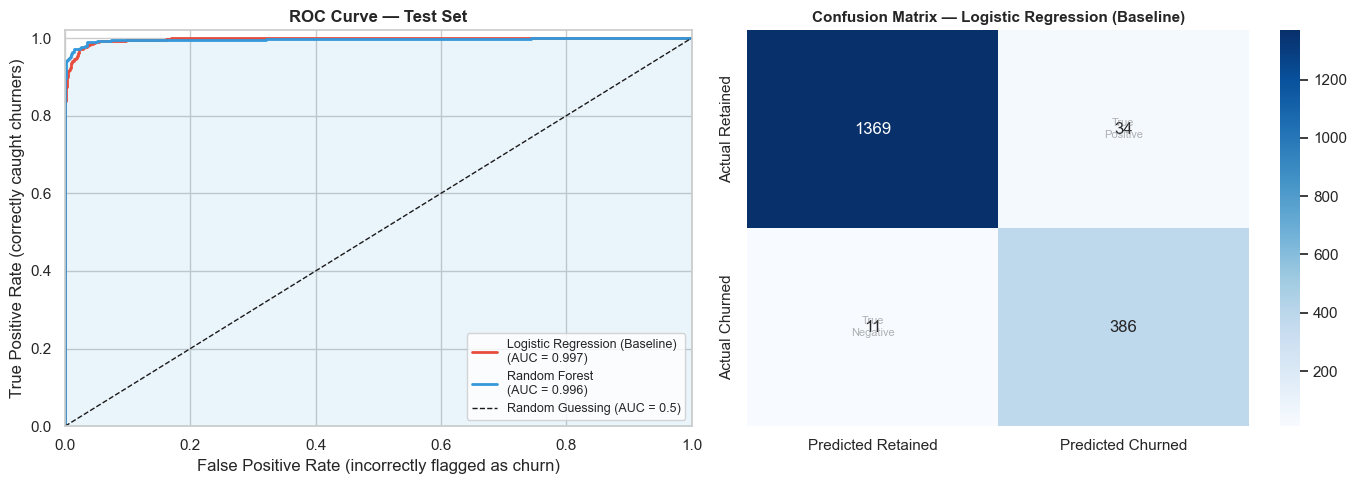

  ✅ Chart saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curve ────────────────────────────────────────────────
ax = axes[0]
colors = ["#E74C3C", "#3498DB"]

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["prob_test"])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name}\n(AUC = {res['test_auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guessing (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.1, color="#3498DB")   # shade under curve
ax.set_title("ROC Curve — Test Set", fontweight="bold", fontsize=12)
ax.set_xlabel("False Positive Rate (incorrectly flagged as churn)")
ax.set_ylabel("True Positive Rate (correctly caught churners)")
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ── Confusion Matrix ─────────────────────────────────────────
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True, fmt="d",       # show actual numbers
    cmap="Blues",
    ax=ax,
    xticklabels=["Predicted Retained", "Predicted Churned"],
    yticklabels=["Actual Retained",    "Actual Churned"]
)
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold", fontsize=11)

# Annotate what each quadrant means
ax.text(0.25, 0.25, "True\nNegative",  ha="center", va="center", transform=ax.transAxes,
        fontsize=8, color="gray", alpha=0.6)
ax.text(0.75, 0.75, "True\nPositive",  ha="center", va="center", transform=ax.transAxes,
        fontsize=8, color="gray", alpha=0.6)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_roc_and_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Chart saved!")

## 🔑 Cell 9: Feature Importance — What Predicts Churn?
Random Forest can tell us which features were most useful for predicting churn.

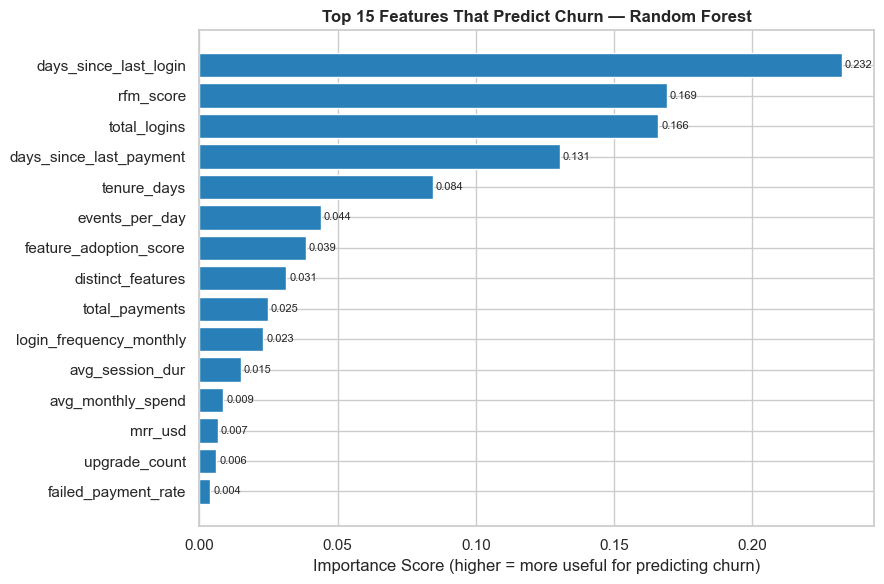

✅ Feature importance chart saved!

  Top 5 churn predictors:
   days_since_last_login               : 0.2323
   rfm_score                           : 0.1690
   total_logins                        : 0.1660
   days_since_last_payment             : 0.1305
   tenure_days                         : 0.0845


In [9]:
# Get the Random Forest model from the pipeline
rf_pipeline = results["Random Forest"]["pipeline"]
rf_clf      = rf_pipeline.named_steps["clf"]

# Get feature names after one-hot encoding
ohe         = rf_pipeline.named_steps["prep"].named_transformers_["encode_text"]
cat_names   = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feat_names = NUMERIC_FEATURES + cat_names

# Get importance scores
importances = pd.Series(rf_clf.feature_importances_, index=all_feat_names)
top15 = importances.nlargest(15).sort_values()

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15.values, color="#2980B9", edgecolor="white")

# Add value labels
for bar, val in zip(bars, top15.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)

ax.set_title("Top 15 Features That Predict Churn — Random Forest",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score (higher = more useful for predicting churn)")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Feature importance chart saved!")
print("\n  Top 5 churn predictors:")
for feat, score in top15.tail(5).iloc[::-1].items():
    print(f"   {feat:<35} : {score:.4f}")

## 💾 Cell 10: Save the Trained Model

In [10]:
# Save the best model to a file using pickle
# This lets us load and reuse it later without retraining
best_pipeline = results[best_name]["pipeline"]
model_path    = f"{MODEL_DIR}/churn_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(best_pipeline, f)

print(f"✅ Model saved to: {model_path}")
print(f"   To reload later: model = pickle.load(open('{model_path}', 'rb'))")

✅ Model saved to: ./outputs/model/churn_model.pkl
   To reload later: model = pickle.load(open('./outputs/model/churn_model.pkl', 'rb'))


## 🚨 Cell 11: Score All Customers — Generate At-Risk List
Use the trained model to score every customer and save a list of high-risk ones.

In [11]:
print("🚨 Scoring all customers...")

# Load full MAT for scoring
all_mat = pd.read_csv(MAT_PATH)

# Prepare the feature matrix — fill missing with column medians
X_all = all_mat[ALL_FEATURES].copy()
X_all = X_all.fillna(X_all.median(numeric_only=True))

# Predict churn probability for every customer
all_mat["churn_probability"] = best_pipeline.predict_proba(X_all)[:, 1]

# Label the score into easy-to-read buckets
all_mat["churn_label"] = pd.cut(
    all_mat["churn_probability"],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=["🟢 Low", "🟡 Medium", "🟠 High", "🔴 Critical"]
)

# Filter: only customers with >50% churn probability
display_cols = [
    "user_id", plan_col, "acquisition_channel",
    "mrr_usd", "tenure_days",
    "churn_probability", "churn_label", "risk_segment"
]
display_cols = [c for c in display_cols if c in all_mat.columns]

at_risk = (
    all_mat[all_mat["churn_probability"] > 0.5]
    .sort_values("churn_probability", ascending=False)
    [display_cols]
)

# Save the at-risk list
at_risk_path = f"{MODEL_DIR}/at_risk_customers.csv"
at_risk.to_csv(at_risk_path, index=False)

print(f"✅ At-risk customers identified: {len(at_risk):,}")
print(f"   MRR at risk: ${at_risk['mrr_usd'].sum():,.0f}")
print(f"   Saved to: {at_risk_path}")

at_risk.head(10)

🚨 Scoring all customers...
✅ At-risk customers identified: 2,962
   MRR at risk: $86,285
   Saved to: ./outputs/model/at_risk_customers.csv


,user_id,acquisition_channel,mrr_usd,tenure_days,churn_probability,churn_label,risk_segment
7465,USR-07466,Organic,9.99,7,1.0,🔴 Critical,High Risk
7143,USR-07144,Social Media,9.99,44,1.0,🔴 Critical,High Risk
3281,USR-03282,Organic,9.99,67,1.0,🔴 Critical,High Risk
9789,USR-09790,Paid Search,66.66,33,1.0,🔴 Critical,High Risk
1427,USR-01428,Direct,8.33,35,1.0,🔴 Critical,High Risk
1008,USR-01009,Direct,8.33,73,1.0,🔴 Critical,High Risk
9178,USR-09179,Organic,9.99,53,1.0,🔴 Critical,High Risk
2610,USR-02611,Referral,79.99,45,1.0,🔴 Critical,High Risk
3352,USR-03353,Email Campaign,9.99,41,1.0,🔴 Critical,High Risk
3226,USR-03227,Social Media,24.99,47,1.0,🔴 Critical,High Risk


## ✅ Cell 12: Final Summary

In [12]:
print("="*55)
print("  ✅ STEP 4 COMPLETE — CHURN MODEL TRAINED")
print("="*55)
print(f"\n  Best Model        : {best_name}")
print(f"  Test AUC-ROC      : {results[best_name]['test_auc']:.4f}")
print(f"  At-Risk Users     : {len(at_risk):,}")
print(f"  MRR at Risk       : ${at_risk['mrr_usd'].sum():,.0f}")
print(f"\n  📂 Model saved    : {MODEL_DIR}/churn_model.pkl")
print(f"  📂 At-risk list   : {MODEL_DIR}/at_risk_customers.csv")
print(f"  📂 Charts         : {CHART_DIR}/")
print(f"""
  👉 Next Step: Build Power BI Dashboard using:
     - data/mat/master_analytics_table.csv
     - outputs/model/at_risk_customers.csv
     - outputs/charts/ (chart images)
""")

  ✅ STEP 4 COMPLETE — CHURN MODEL TRAINED

  Best Model        : Logistic Regression (Baseline)
  Test AUC-ROC      : 0.9971
  At-Risk Users     : 2,962
  MRR at Risk       : $86,285

  📂 Model saved    : ./outputs/model/churn_model.pkl
  📂 At-risk list   : ./outputs/model/at_risk_customers.csv
  📂 Charts         : ./outputs/charts/

  👉 Next Step: Build Power BI Dashboard using:
     - data/mat/master_analytics_table.csv
     - outputs/model/at_risk_customers.csv
     - outputs/charts/ (chart images)

